## Сингулярный спектральный анализ: как длина окна меняет разложение ряда

Ряд из папки `Series` - месячное число пассажиров международных авиалиний, 144 точки
с января 1949 по декабрь 1960 года. Из шести предложенных рядов этот подходит к SSA
лучше остальных: в нем одновременно есть растущий нелинейный тренд и годовая волна,
амплитуда которой увеличивается вместе с уровнем. Скользящее среднее такую пару
размывает на краях, а разложению Фурье нужна постоянная амплитуда колебания.

Длина окна `L` - единственный параметр метода, и работа посвящена тому, что именно он
меняет. Взяты пять окон: 6 (короче периода), 12 (ровно период), 24 и 36 (два и три
периода) и 72 (предельное значение `N/2`). Для каждого считается разложение, строится
матрица W-корреляций, компоненты собираются в тренд, сезонность и шум, а результаты
сводятся в одну таблицу

### Задача 1. Ряд и его структура

Прежде чем выбирать длину окна, надо посмотреть, что в ряде вообще есть. Для SSA важны
две вещи: период колебания, потому что окно принято брать кратным ему, и то, постоянна
ли амплитуда этого колебания.

Амплитуда меряется так: из ряда вычитается центрированное скользящее среднее
за 12 месяцев, и размах того, что осталось, сравнивается на первых и последних трех годах

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

df = pd.read_csv('international-airline-passengers.csv').dropna()
ряд = pd.Series(df['Count'].astype(float).values, index=pd.to_datetime(df['Month']))
N = len(ряд)

# календарь собирается заново и сверяется с фактическим: пропуск внутри ряда сломал бы
# вложение молча - траекторная матрица строится по номерам точек, а не по датам
полный = pd.date_range(ряд.index.min(), ряд.index.max(), freq='MS')
print('точек:', N, '| с', ряд.index.min().date(), 'по', ряд.index.max().date())
print('пропущенных месяцев:', len(полный.difference(ряд.index)))
print('уровень: от', ряд.min(), 'до', ряд.max())

точек: 144 | с 1949-01-01 по 1960-12-01
пропущенных месяцев: 0
уровень: от 104.0 до 622.0


1949-1951: средний уровень  145.5, размах сезонного отклонения   65.9
1958-1960: средний уровень  428.5, размах сезонного отклонения  228.2


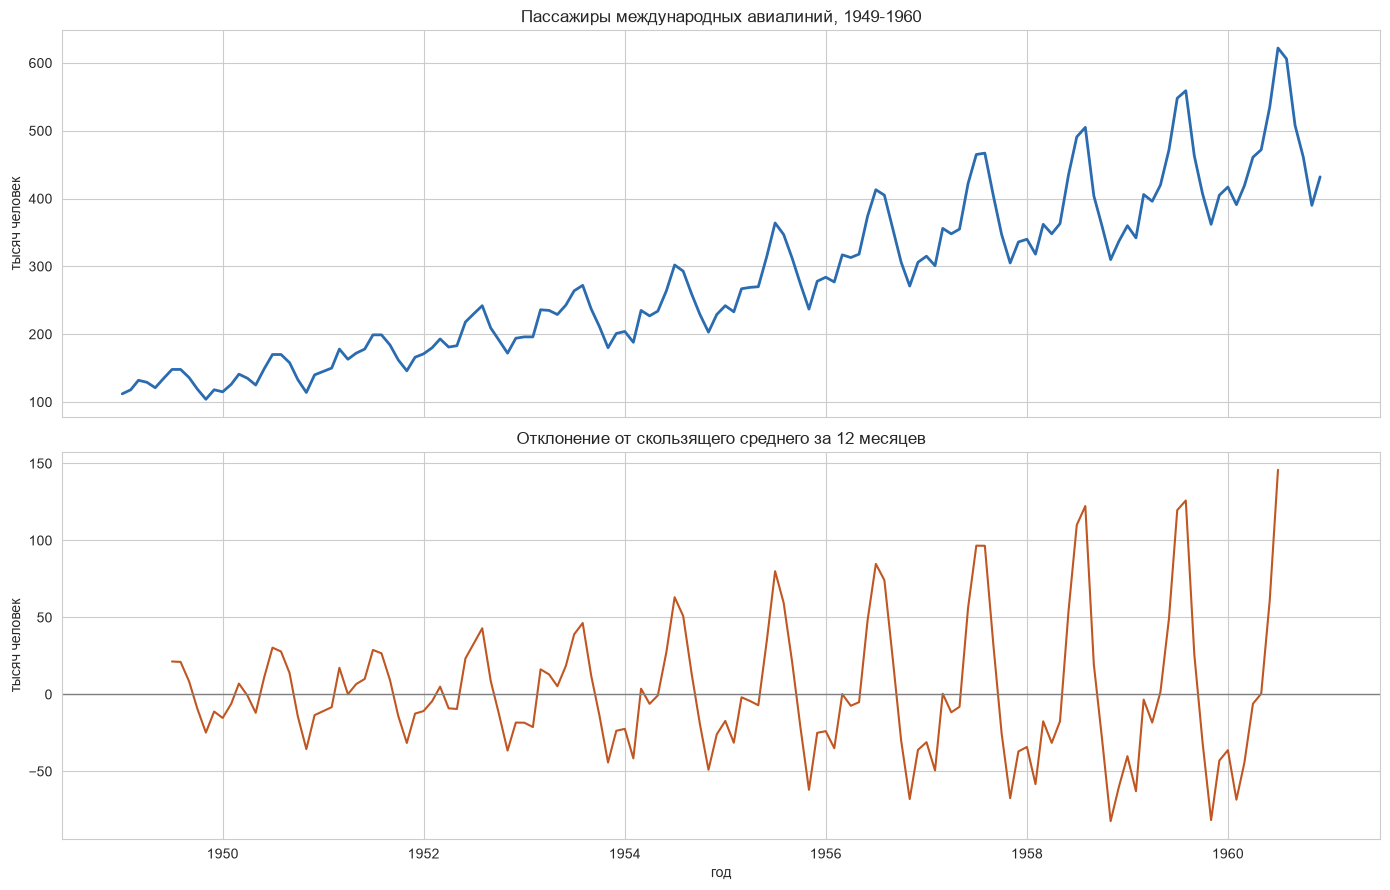

In [2]:
# сезонное отклонение = ряд минус центрированное скользящее среднее за год
отклонение = ряд - ряд.rolling(12, center=True).mean()

for начало, конец, имя in [(0, 36, '1949-1951'), (108, 144, '1958-1960')]:
    кусок = отклонение.iloc[начало:конец].dropna()
    уровень = ряд.iloc[начало:конец].mean()
    print(f'{имя}: средний уровень {уровень:6.1f}, '
          f'размах сезонного отклонения {кусок.max() - кусок.min():6.1f}')

fig, ax = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
ax[0].plot(ряд.index, ряд.values, lw=2, color='#2b6cb0')
ax[0].set_title('Пассажиры международных авиалиний, 1949-1960')
ax[0].set_ylabel('тысяч человек')
ax[1].plot(отклонение.index, отклонение.values, lw=1.5, color='#c05621')
ax[1].axhline(0, color='gray', lw=1)
ax[1].set_title('Отклонение от скользящего среднего за 12 месяцев')
ax[1].set_xlabel('год')
ax[1].set_ylabel('тысяч человек')
plt.tight_layout()
plt.show()

**Вывод по Задаче 1:** ряд полный, 144 месяца подряд без пропусков, и в нем видны обе
структуры сразу. Средний уровень вырос втрое - со 145 до 428, а размах сезонного
отклонения за то же время вырос с 66 до 228, то есть в 3.5 раза. Амплитуда колебания
растет вместе с уровнем: сезонность здесь **мультипликативная**, а не постоянная
по величине.

Период колебания - 12 месяцев, пик приходится на июль и август, провал на ноябрь
и февраль. Значит, длины окна разумно брать кратными 12, и оттуда же берется верхняя
граница: при `N = 144` окно не может быть длиннее 72

### Задача 2. Разложение SSA с разными длинами окна

Алгоритм собирается по шагам из презентации: **вложение** превращает ряд в траекторную
матрицу размера `L` на `K = N - L + 1`, **сингулярное разложение** дает набор элементарных
матриц, **диагональное усреднение** возвращает каждую из них обратно в ряд длины `N`.

Реализация проверяется тождеством: сумма всех восстановленных компонент
обязана в точности давать исходный ряд. Ошибка в диагональном усреднении вылезла бы
на этой проверке сразу

In [3]:
class SSA:
    """Сингулярный спектральный анализ ряда с длиной окна L."""

    def __init__(self, ряд, L):
        self.ряд = pd.Series(np.asarray(ряд, dtype=float))
        self.N = len(self.ряд)
        if not 2 <= L <= self.N / 2:
            raise ValueError('длина окна должна лежать между 2 и N/2')
        self.L = L
        self.K = self.N - L + 1

        # шаг 1, вложение: столбцы траекторной матрицы - отрезки ряда длины L
        # со сдвигом в один месяц
        x = self.ряд.values
        self.X = np.column_stack([x[i:i + L] for i in range(self.K)])

        # шаг 2, сингулярное разложение
        self.U, self.Sigma, VT = np.linalg.svd(self.X, full_matrices=False)
        self.d = int(np.linalg.matrix_rank(self.X))
        self.вклад = self.Sigma ** 2 / (self.Sigma ** 2).sum()

        # шаг 3, диагональное усреднение: каждая элементарная матрица снова
        # становится рядом длины N
        self.компоненты = np.zeros((self.N, self.d))
        for i in range(self.d):
            Xi = self.Sigma[i] * np.outer(self.U[:, i], VT[i, :])
            перевернутая = Xi[::-1]
            self.компоненты[:, i] = [перевернутая.diagonal(j).mean()
                                     for j in range(-self.L + 1, self.K)]
        self.W = self._w_корреляции()

    def _w_корреляции(self):
        # вес точки равен числу элементов на ее антидиагонали: у краев ряда
        # усреднять почти нечего, поэтому края весят меньше середины
        L, K = self.L, self.K
        w = np.array(list(np.arange(L) + 1) + [L] * (K - L - 1) + list(np.arange(L) + 1)[::-1])
        F = self.компоненты
        нормы = np.array([w.dot(F[:, i] ** 2) for i in range(self.d)]) ** -0.5
        W = np.identity(self.d)
        for i in range(self.d):
            for j in range(i + 1, self.d):
                W[i, j] = W[j, i] = abs(w.dot(F[:, i] * F[:, j]) * нормы[i] * нормы[j])
        return W

    def собрать(self, индексы):
        """Сумма выбранных компонент - восстановленный ряд."""
        индексы = list(индексы)
        if not индексы:
            return np.zeros(self.N)
        return self.компоненты[:, индексы].sum(axis=1)

Разложение считается для пяти окон сразу, и тождество проверяется на каждом

In [4]:
окна = [6, 12, 24, 36, 72]
разложения = {L: SSA(ряд.values, L) for L in окна}

for L in окна:
    s = разложения[L]
    расхождение = np.abs(ряд.values - s.собрать(range(s.d))).max()
    print(f'L = {L:2d}: K = {s.K:3d}, компонент {s.d:2d}, '
          f'максимальное расхождение с рядом {расхождение:.2e}')

L =  6: K = 139, компонент  6, максимальное расхождение с рядом 3.55e-13
L = 12: K = 133, компонент 12, максимальное расхождение с рядом 1.17e-12
L = 24: K = 121, компонент 24, максимальное расхождение с рядом 7.39e-13
L = 36: K = 109, компонент 36, максимальное расхождение с рядом 6.54e-13
L = 72: K =  73, компонент 72, максимальное расхождение с рядом 6.82e-13


Сингулярный спектр показывает, как энергия ряда распределена по компонентам. У правильно
выделенного колебания вклады идут почти равной парой: гармоника раскладывается на два
сдвинутых по фазе слагаемых, и обе половины несут одинаковую энергию

Вклад первых шести компонент в дисперсию, %
               L = 6  L = 12  L = 24  L = 36  L = 72
компонента 0  98.571  97.989  97.962  97.958  97.982
компонента 1   0.931   0.734   0.721   0.706   0.692
компонента 2   0.346   0.731   0.718   0.700   0.680
компонента 3   0.086   0.198   0.194   0.190   0.182
компонента 4   0.044   0.195   0.192   0.188   0.180
компонента 5   0.022   0.037   0.041   0.061   0.054


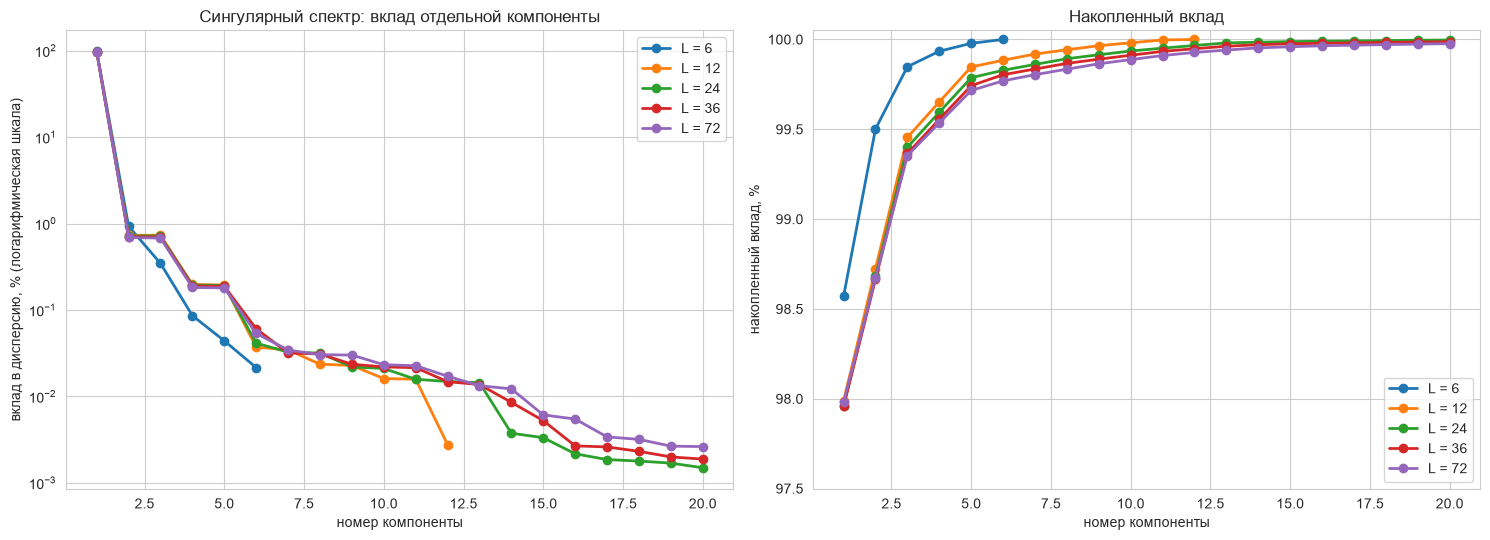

In [5]:
таблица_вкладов = pd.DataFrame(
    {f'L = {L}': np.round(разложения[L].вклад[:6] * 100, 3) for L in окна},
    index=[f'компонента {i}' for i in range(6)])
print('Вклад первых шести компонент в дисперсию, %')
print(таблица_вкладов.to_string())

fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
for L in окна:
    s = разложения[L]
    сколько = min(s.d, 20)
    ax[0].plot(range(1, сколько + 1), s.вклад[:сколько] * 100, marker='o', lw=2, label=f'L = {L}')
    ax[1].plot(range(1, сколько + 1), np.cumsum(s.вклад[:сколько]) * 100, marker='o', lw=2, label=f'L = {L}')
ax[0].set_yscale('log')
ax[0].set_title('Сингулярный спектр: вклад отдельной компоненты')
ax[0].set_xlabel('номер компоненты')
ax[0].set_ylabel('вклад в дисперсию, % (логарифмическая шкала)')
ax[0].legend()
ax[1].set_ylim(97.5, 100.05)
ax[1].set_title('Накопленный вклад')
ax[1].set_xlabel('номер компоненты')
ax[1].set_ylabel('накопленный вклад, %')
ax[1].legend()
plt.tight_layout()
plt.show()

**Вывод по Задаче 2:** реализация верна - сумма всех компонент воспроизводит ряд
с расхождением на уровне машинной точности при любой длине окна.

Число компонент равно длине окна: при `L = 6` их шесть, при `L = 72` их семьдесят две.
Отсюда первое следствие, видное уже по таблице вкладов. При `L = 6` вторая и третья
компоненты дают 0.931% и 0.346% - это не пара, а две разные вещи. Начиная с `L = 12`
вклады выстраиваются почти равными парами: 0.734 и 0.731 при `L = 12`, 0.706 и 0.700
при `L = 36`. Окно короче периода не дает годовому колебанию встать парой: полный годовой
цикл в отрезок длины 6 не помещается.

На первую компоненту везде приходится около 98% дисперсии, и эта доля от длины окна
почти не зависит. Все различия между окнами сидят в оставшихся двух процентах

### Задача 3. Матрицы W-корреляций

Сингулярный спектр говорит, сколько энергии у компоненты, но не говорит, с кем ее
объединять. Для этого считается **W-корреляция** - взвешенная корреляция между парой
восстановленных рядов, где вес точки равен числу элементов на ее антидиагонали.
Значение около единицы означает, что компоненты описывают одну и ту же структуру
и должны идти в одну группу; около нуля - что они разделены.

Матрица строится для каждого из пяти окон. Сначала целиком, потом крупным планом
по первым четырнадцати компонентам - именно там читается блочная структура,
а дальше идет шумовой хвост

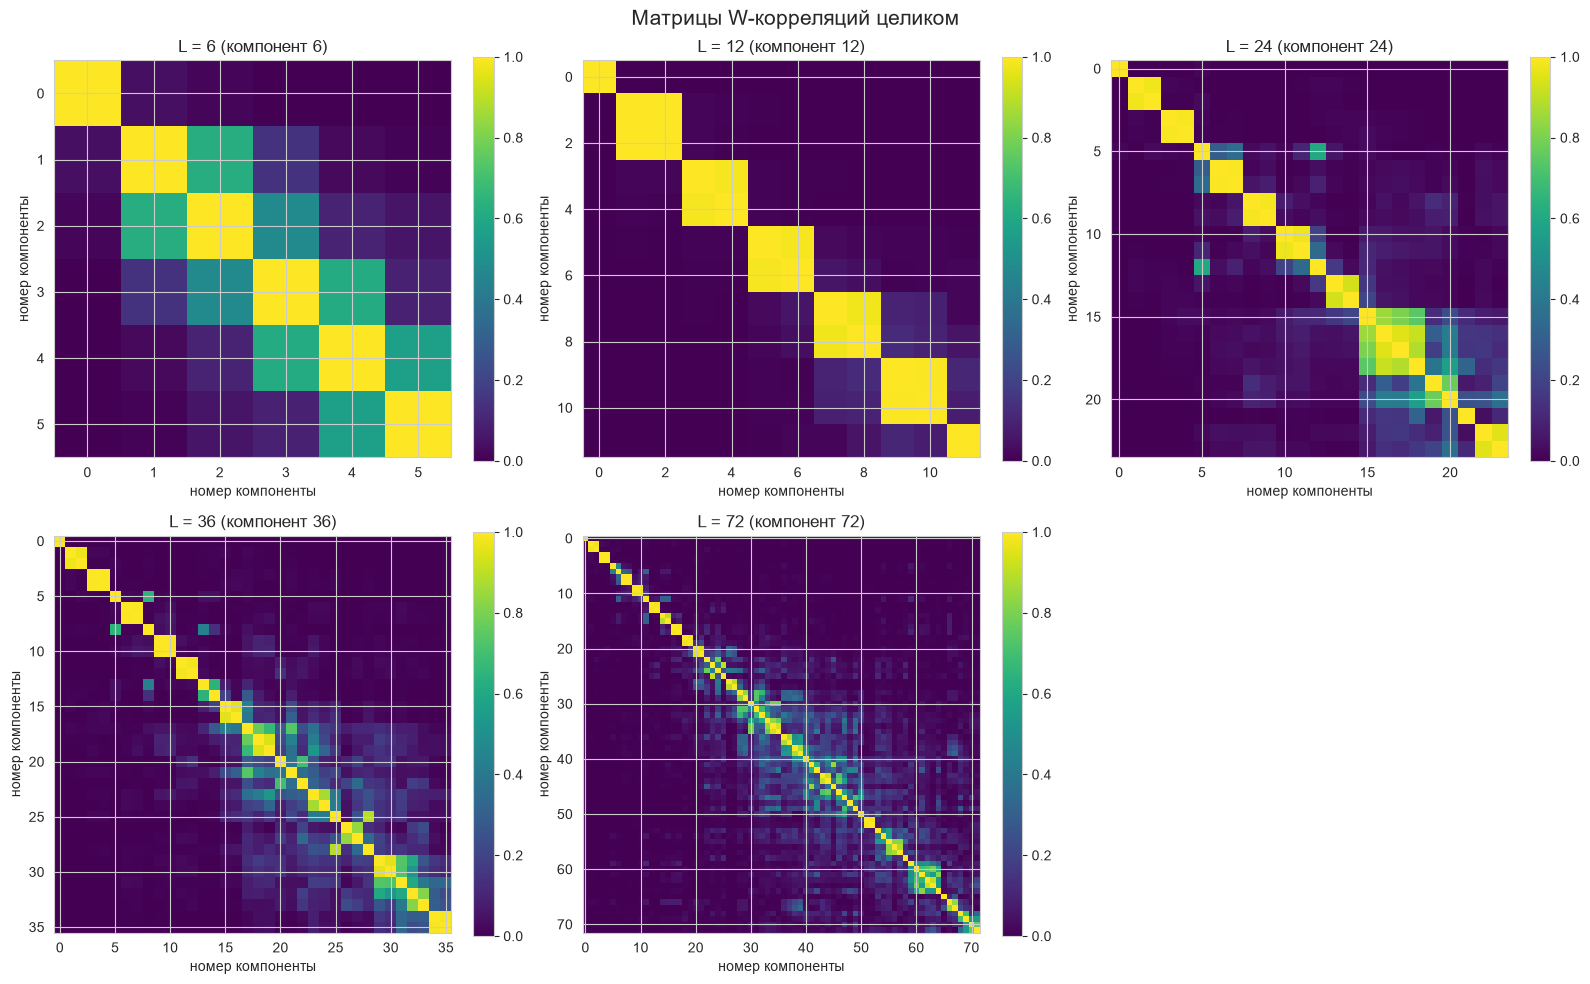

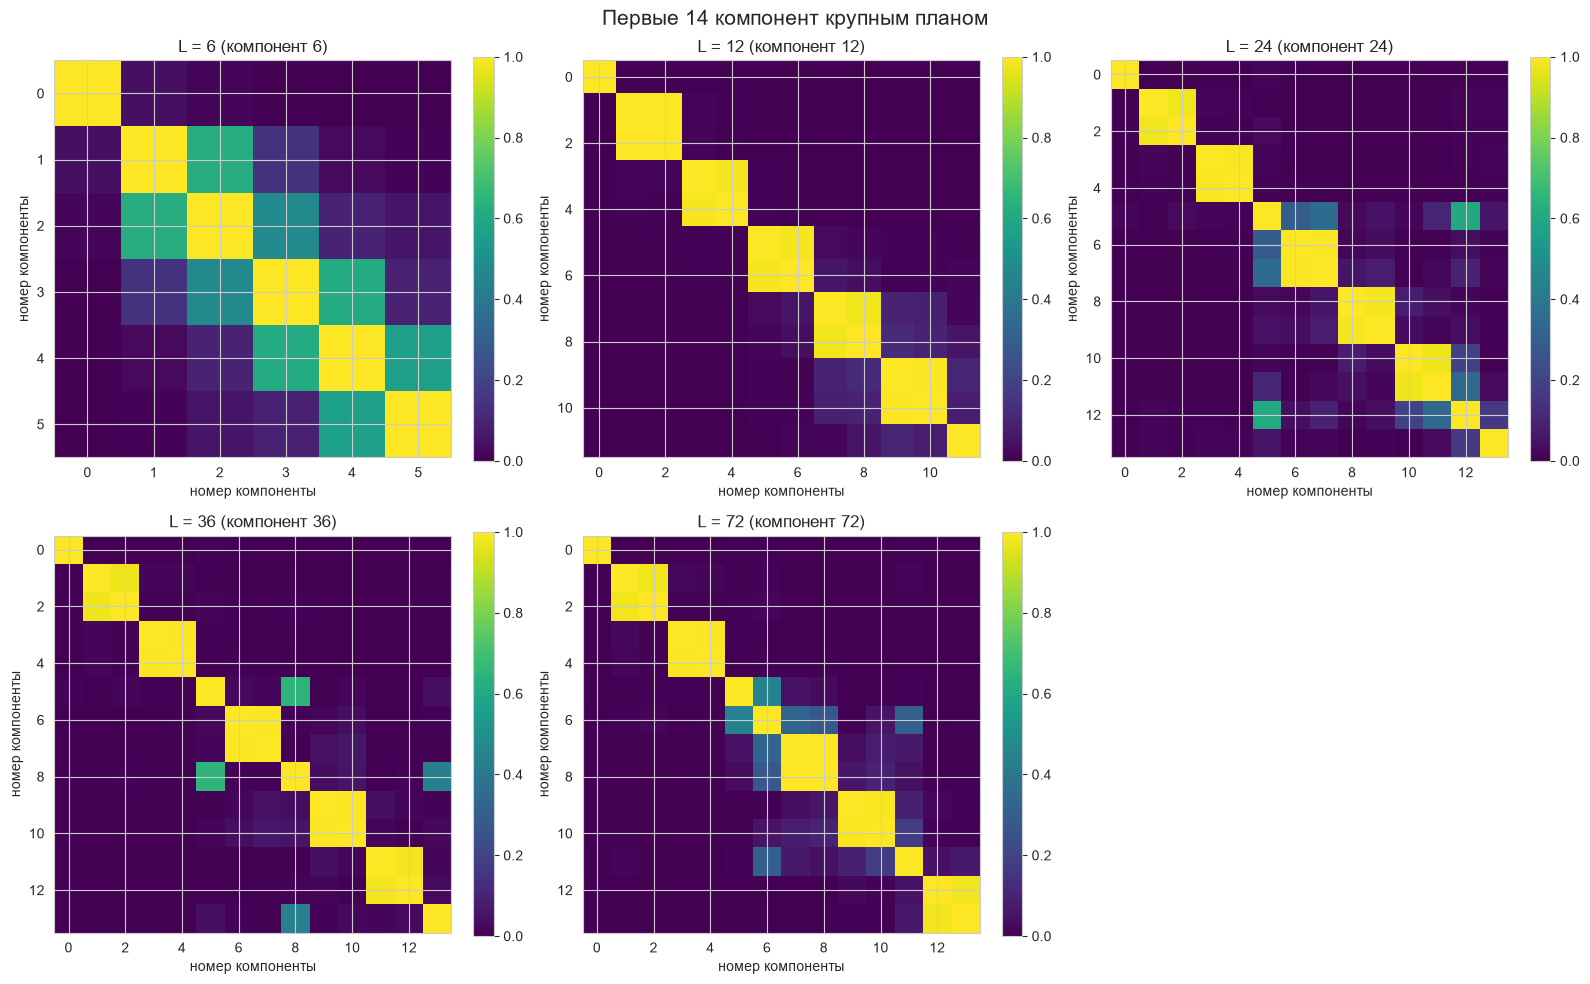

In [6]:
def нарисовать_wкорреляции(предел=None, заголовок=''):
    fig, оси = plt.subplots(2, 3, figsize=(16, 10))
    for ось, L in zip(оси.ravel(), окна):
        s = разложения[L]
        n = s.d if предел is None else min(предел, s.d)
        картинка = ось.imshow(s.W[:n, :n], vmin=0, vmax=1, cmap='viridis')
        ось.set_title(f'L = {L} (компонент {s.d})')
        ось.set_xlabel('номер компоненты')
        ось.set_ylabel('номер компоненты')
        fig.colorbar(картинка, ax=ось, fraction=0.046)
    оси.ravel()[-1].axis('off')
    fig.suptitle(заголовок, fontsize=15)
    plt.tight_layout()
    plt.show()


нарисовать_wкорреляции(None, 'Матрицы W-корреляций целиком')
нарисовать_wкорреляции(14, 'Первые 14 компонент крупным планом')

Блоки на картинке видны, но вывод о разделимости лучше подкрепить числом.
Годовая волна - главная структура ряда после тренда, поэтому меряется она: насколько
компоненты годовой пары связаны между собой и насколько они изолированы от всего
остального разложения

In [7]:
шаг_сетки = 1.0 / N                      # шаг частотной сетки для ряда из N точек
гармоники = [k / 12 for k in range(1, 7)]  # годовая волна и пять ее гармоник


def главная_частота(x):
    """Частота с наибольшей мощностью, в циклах на месяц."""
    спектр = np.abs(np.fft.rfft(x - x.mean())) ** 2
    частоты = np.fft.rfftfreq(len(x))
    if спектр[1:].sum() == 0:
        return 0.0
    return частоты[1:][np.argmax(спектр[1:])]


строки = []
for L in окна:
    s = разложения[L]
    частота = np.array([главная_частота(s.компоненты[:, i]) for i in range(s.d)])
    # годовая пара - компоненты с главной частотой ровно в 1/12, с наибольшим вкладом
    годовые = [i for i in range(s.d) if abs(частота[i] - 1 / 12) <= 0.6 * шаг_сетки][:2]
    внутри = s.W[годовые[0], годовые[1]] if len(годовые) == 2 else np.nan
    снаружи = max(max(s.W[i, j] for j in range(s.d) if j not in годовые) for i in годовые)
    строки.append({'L': L, 'компонент с частотой 1/12': len(годовые),
                   'W внутри пары': round(внутри, 4) if len(годовые) == 2 else '-',
                   'максимум W с остальными': round(снаружи, 4)})

print(pd.DataFrame(строки).to_string(index=False))

 L  компонент с частотой 1/12 W внутри пары  максимум W с остальными
 6                          1             -                   0.6222
12                          2        0.9995                   0.0159
24                          2        0.9796                   0.0251
36                          2        0.9741                   0.0189
72                          2        0.9769                   0.0247


**Вывод по Задаче 3:** пять матриц выглядят по-разному, и различаются они двумя вещами -
насколько чисто отделены друг от друга парные блоки и есть ли у разложения шумовой хвост.

При `L = 6` окрашены почти все клетки вне диагонали, значения доходят до 0.6:
шести компонент не хватает, чтобы структуры разошлись по разным местам, и каждая
перепутана с каждой. При `L = 12` картина обратная и самая чистая из пяти - ровная
блочная диагональ из пяти парных квадратов и двух одиночных компонент, вне блоков
почти ноль. Шумового угла при этом нет ни там, ни там: все компоненты заняты делом.

При `L = 24, 36, 72` слева сверху остаются те же парные блоки, а в правом нижнем углу
разрастается область взаимно перепутанных компонент - это и есть шум. Чем длиннее окно,
тем она больше: при `L = 24` она начинается примерно с пятнадцатой компоненты,
при `L = 72` - с двадцатой и занимает большую часть матрицы.

Числа подтверждают то, что было видно по вкладам. При `L = 6` компонента с годовой
частотой всего одна, пары нет, и ее максимальная W-корреляция с остальными - **0.62**:
годовая волна размазана по разложению. Начиная с `L = 12` пара есть, внутри нее
W-корреляция 0.97-0.99, то есть половины действительно описывают одно колебание,
а связь с остальными компонентами падает до 0.016-0.025. Это и означает, что пару
можно вынимать целиком

### Задача 4. Сравнение окон и выбор длины

Компоненты пора собрать в группы. Правило берется формальное и одинаковое для всех окон,
чтобы сравнение не зависело от того, как рука разложила компоненты в конкретном случае:
в **тренд** идет все, у чего главный период длиннее двух лет, в **сезонность** - все,
у чего главная частота попадает в годовую гармонику, остальное - **шум**.

Качество разложения меряется так: сколько компонент попало в каждую группу, насколько
равны вклады в годовой паре, насколько тренд загрязнен сезонностью - по доле мощности
на годовой частоте и по размаху ряби, которая остается от тренда после сглаживания
за год, - какой высоты получается сезонная волна и сколько ряда осталось в остатке
после вычитания тренда и сезонности

In [8]:
def доля_на_частоте(x, f0, ширина=0.6):
    """Доля мощности ряда, приходящаяся на частоту f0."""
    спектр = np.abs(np.fft.rfft(x - x.mean())) ** 2
    частоты = np.fft.rfftfreq(len(x))
    if спектр.sum() == 0:
        return 0.0
    return спектр[np.abs(частоты - f0) <= ширина * шаг_сетки].sum() / спектр.sum()


def сгруппировать(s):
    """Делит компоненты разложения на тренд, сезонность и шум."""
    частота = np.array([главная_частота(s.компоненты[:, i]) for i in range(s.d)])
    тренд = [i for i in range(s.d) if частота[i] < 1 / 24]
    сезон = [i for i in range(s.d) if i not in тренд
             and min(abs(частота[i] - g) for g in гармоники) <= 0.6 * шаг_сетки]
    шум = [i for i in range(s.d) if i not in тренд + сезон]
    return тренд, сезон, шум


сводка, группы = [], {}
for L in окна:
    s = разложения[L]
    тренд_и, сезон_и, шум_и = сгруппировать(s)
    группы[L] = (тренд_и, сезон_и, шум_и)
    тренд = s.собрать(тренд_и)
    сезон = s.собрать(сезон_и)
    остаток = ряд.values - тренд - сезон
    # рябь тренда - то, что остается от него после сглаживания за год: у чистого тренда
    # ее почти нет, у загрязненного сезонностью она видна на графике
    рябь = тренд - pd.Series(тренд).rolling(13, center=True).mean().values
    годовые = [i for i in сезон_и if abs(главная_частота(s.компоненты[:, i]) - 1 / 12) <= 0.6 * шаг_сетки][:2]
    сводка.append({
        'L': L,
        'компонент': s.d,
        'K': s.K,
        'в тренде': len(тренд_и),
        'в сезонности': len(сезон_и),
        'в шуме': len(шум_и),
        'отношение вкладов в паре': round(s.вклад[годовые[1]] / s.вклад[годовые[0]], 4) if len(годовые) == 2 else '-',
        'годовая частота в тренде, %': round(доля_на_частоте(тренд, 1 / 12) * 100, 3),
        'размах ряби тренда': round(float(np.nanmax(рябь) - np.nanmin(рябь)), 1),
        'пик сезонной волны': round(float(сезон[-48:].max()), 1),
        'RMSE остатка': round(float(np.sqrt((остаток ** 2).mean())), 3),
        'остаток, % от среднего': round(float(np.sqrt((остаток ** 2).mean()) / ряд.mean() * 100), 3),
    })

сводка = pd.DataFrame(сводка)
print(сводка.to_string(index=False))

 L  компонент   K  в тренде  в сезонности  в шуме отношение вкладов в паре  годовая частота в тренде, %  размах ряби тренда  пик сезонной волны  RMSE остатка  остаток, % от среднего
 6          6 139         1             5       0                        -                        1.895                73.1               106.3         0.000                   0.000
12         12 133         1            11       0                    0.996                        0.436                 3.7               137.4         0.000                   0.000
24         24 121         2            11      11                   0.9958                        0.441                 6.2               136.4         3.958                   1.412
36         36 109         3            12      21                   0.9916                        0.421                 4.7               136.0         4.912                   1.752
72         72  73         6            11      55                    0.982                

Дальше - сами восстановленные компоненты. Тренды пяти окон кладутся на один график,
сезонные волны - на другой, за последние четыре года, чтобы их было видно

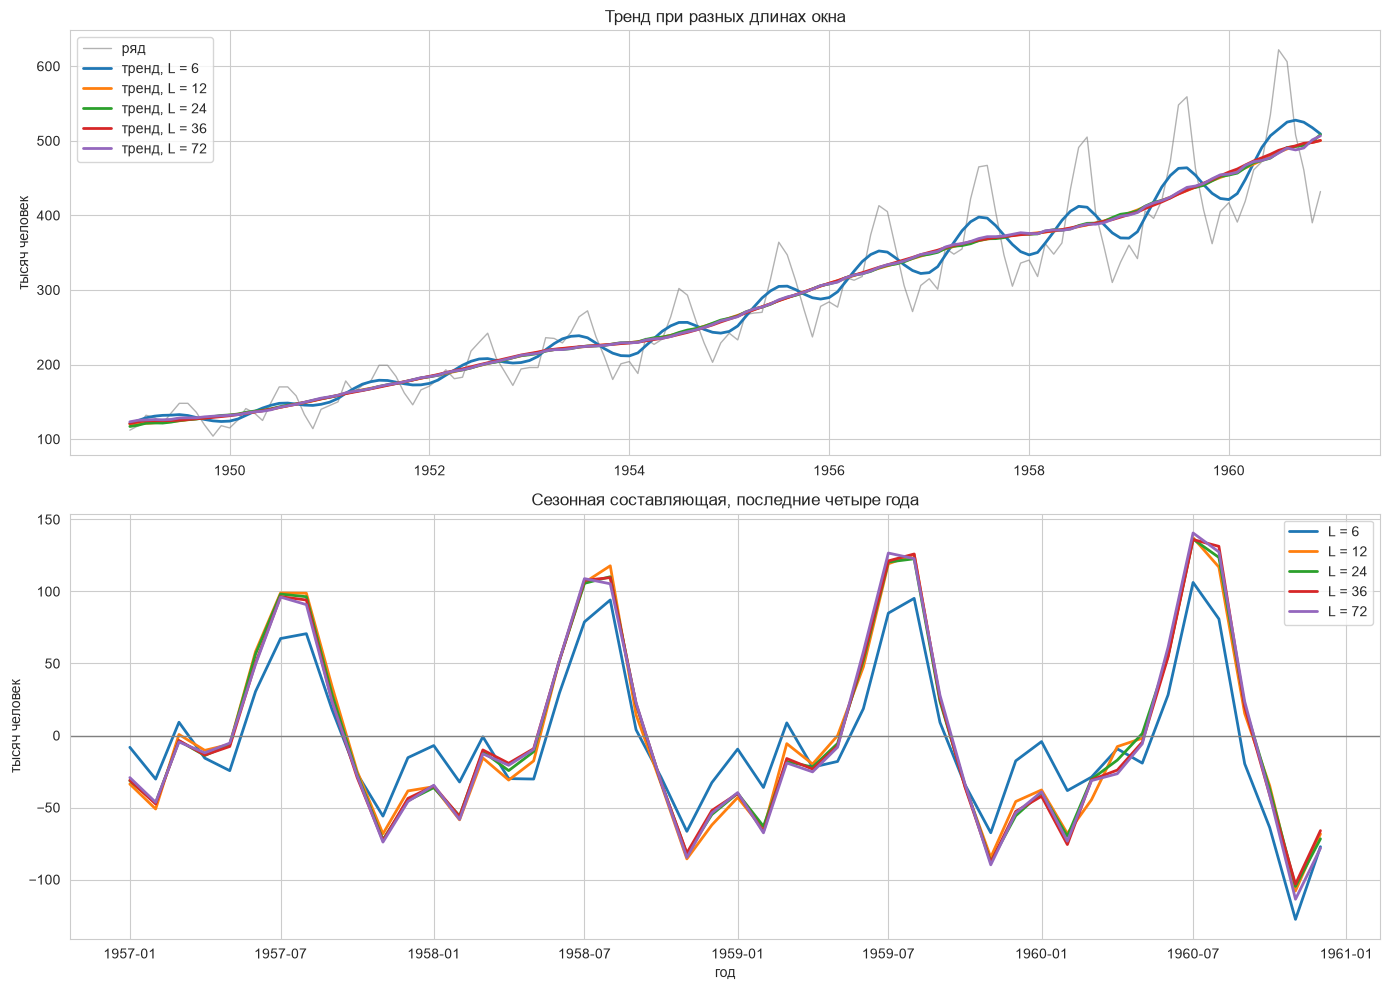

In [9]:
fig, ax = plt.subplots(2, 1, figsize=(14, 10))
ax[0].plot(ряд.index, ряд.values, lw=1, color='gray', alpha=0.6, label='ряд')
for L in окна:
    ax[0].plot(ряд.index, разложения[L].собрать(группы[L][0]), lw=2, label=f'тренд, L = {L}')
ax[0].set_title('Тренд при разных длинах окна')
ax[0].set_ylabel('тысяч человек')
ax[0].legend()

хвост = slice(-48, None)
for L in окна:
    ax[1].plot(ряд.index[хвост], разложения[L].собрать(группы[L][1])[хвост], lw=2, label=f'L = {L}')
ax[1].axhline(0, color='gray', lw=1)
ax[1].set_title('Сезонная составляющая, последние четыре года')
ax[1].set_xlabel('год')
ax[1].set_ylabel('тысяч человек')
ax[1].legend()
plt.tight_layout()
plt.show()

Пять окон показывают направление, но не границы. Чтобы ответить, какое окно брать,
те же две величины считаются подряд для всех длин от 6 до 72: насколько равны вклады
в годовой паре и насколько пара изолирована от остального разложения

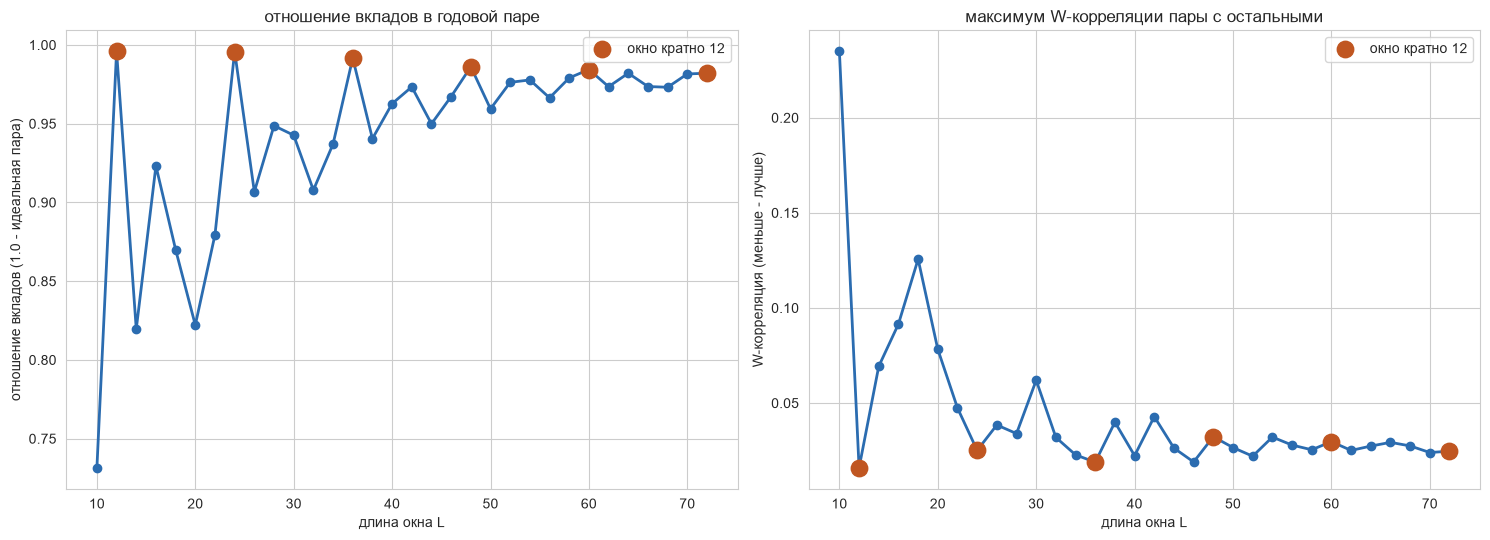

Развертка по всем длинам окна (со звездочкой - кратные 12):
   L  равенство пары  изоляция пары
   6             NaN            NaN
   8             NaN            NaN
  10          0.7315         0.2349
12 *          0.9960         0.0159
  14          0.8196         0.0693
  16          0.9232         0.0915
  18          0.8700         0.1256
  20          0.8221         0.0783
  22          0.8795         0.0474
24 *          0.9958         0.0251
  26          0.9068         0.0385
  28          0.9487         0.0340
  30          0.9427         0.0620
  32          0.9078         0.0319
  34          0.9371         0.0228
36 *          0.9916         0.0189
  38          0.9405         0.0399
  40          0.9627         0.0224
  42          0.9733         0.0429
  44          0.9499         0.0263
  46          0.9672         0.0190
48 *          0.9861         0.0323
  50          0.9594         0.0266
  52          0.9762         0.0221
  54          0.9778         0.0321
  56

In [10]:
развертка = []
for L in range(6, 73, 2):
    s = SSA(ряд.values, L)
    частота = np.array([главная_частота(s.компоненты[:, i]) for i in range(s.d)])
    годовые = [i for i in range(s.d) if abs(частота[i] - 1 / 12) <= 0.6 * шаг_сетки][:2]
    if len(годовые) < 2:
        развертка.append({'L': L, 'равенство пары': np.nan, 'изоляция пары': np.nan})
        continue
    развертка.append({
        'L': L,
        'равенство пары': s.вклад[годовые[1]] / s.вклад[годовые[0]],
        'изоляция пары': max(max(s.W[i, j] for j in range(s.d) if j not in годовые) for i in годовые)})
развертка = pd.DataFrame(развертка)

fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
кратные = развертка['L'] % 12 == 0
for k, (столбец, подпись) in enumerate([('равенство пары', 'отношение вкладов в годовой паре'),
                                        ('изоляция пары', 'максимум W-корреляции пары с остальными')]):
    ax[k].plot(развертка['L'], развертка[столбец], marker='o', lw=2, color='#2b6cb0')
    ax[k].scatter(развертка.loc[кратные, 'L'], развертка.loc[кратные, столбец],
                  s=140, color='#c05621', zorder=5, label='окно кратно 12')
    ax[k].set_title(подпись)
    ax[k].set_xlabel('длина окна L')
    ax[k].legend()
ax[0].set_ylabel('отношение вкладов (1.0 - идеальная пара)')
ax[1].set_ylabel('W-корреляция (меньше - лучше)')
plt.tight_layout()
plt.show()

print('Развертка по всем длинам окна (со звездочкой - кратные 12):')
показ = развертка.copy()
показ['L'] = [f'{L} *' if L % 12 == 0 else str(L) for L in показ['L']]
print(показ.round(4).to_string(index=False))

**Вывод по Задаче 4:** длина окна меняет не точность восстановления, а то, из чего
разложение состоит, и влияет она сразу по трем направлениям.

*   **Окно короче периода не разделяет структуры.** При `L = 6` годовая волна не встает
    парой, а тренд загрязнен годовой гармоникой: на нее приходится **1.90%** мощности
    тренда против 0.42-0.44% у всех остальных окон. На графике это видно прямо -
    тренд идет волнистой линией с размахом ряби 73 против 4-8 у остальных окон.
    Забранное трендом теряет сезонность: ее пик за последние четыре года 106 против
    136-141 у всех прочих окон. Компонент всего шесть, шумовой группы нет - весь шум
    сидит внутри тренда и сезонности.
*   **Окно, равное периоду, разделяет структуры, но ничего не фильтрует.** При `L = 12`
    пара уже правильная (вклады 0.734 и 0.731), но компонент ровно двенадцать, и все
    двенадцать попадают в сигнал. Остаток равен нулю: ряд восстановлен точно, то есть
    шум никуда не убран, он распределен по тем же компонентам.
*   **Длинное окно отделяет шум, но начинает дробить тренд.** При `L = 24` в шум уходит
    11 компонент, при `L = 36` - 21, при `L = 72` - 55, и остаток растет с 3.96 до 5.60,
    с 1.4% до 2.0% от среднего уровня. Одновременно тренд перестает быть одной вещью:
    при `L = 24` он собран из 2 компонент, при `L = 36` из 3, при `L = 72` уже из 6.
    Равенство вкладов в годовой паре тоже медленно портится - 0.996 при `L = 24`
    против 0.982 при `L = 72`.

Отдельный результат дала развертка по всем длинам: **кратность периоду важнее самой
длины**. По равенству вкладов в паре каждое кратное окно - локальный максимум, без
единого исключения: 0.9916 при `L = 36` против 0.9371 при `L = 34` и 0.9405 при `L = 38`.
Окно, не кратное периоду, обрывает годовой цикл на середине, и часть его энергии уходит
в соседние компоненты.

Сила этого эффекта падает с длиной окна. На коротких окнах разрыв большой - 0.870
при `L = 18` и 0.943 при `L = 30` против 0.996 при `L = 12` и `L = 24`; на длинных он
сжимается до сотых - 0.974 при `L = 66` против 0.982 при `L = 72`. По изоляции пары
кратность видна только на коротких окнах (0.126 при `L = 18` и 0.062 при `L = 30`
против 0.016-0.025 у кратных), а дальше разница стирается совсем: при `L = 46` изоляция
0.019, то есть лучше, чем у кратного `L = 48` с его 0.032.

**Для этого ряда я бы взяла `L = 36`** - три полных года. Это компромисс по всем трем
направлениям сразу: пара сформирована почти идеально (0.992), изоляция пары лучшая
из пяти рассмотренных окон с непустой шумовой группой (0.019), загрязнение тренда
годовой гармоникой наименьшее из всех окон (0.42%), в шум уходит 21 компонента,
а тренд еще не рассыпался - он собран из трех компонент против шести при `L = 72`.
Траекторная матрица при этом сохраняет 109 столбцов: материала для оценки достаточно

### Дополнительный эксперимент (вне рамок задания)

Задание про разложение, а не про прогноз, но длину окна выбирают обычно под задачу.
Здесь проверяется, совпадает ли выбор, если мерить не чистоту разложения, а ошибку
прогноза на 12 месяцев вперед.

Прогноз строится **линейным рекуррентным соотношением**: по выбранным собственным
векторам считаются коэффициенты, которыми каждая следующая точка выражается через
`L - 1` предыдущих, и ряд продолжается вперед.

Разделение делается **по времени**: последние 12 месяцев 1960 года откладываются
и в разложении не участвуют вообще - SSA заново считается только по первым 132 точкам.
Число компонент фиксируется заранее и одинаково для всех окон: 7 - это тренд и три
первые гармонические пары. Ориентир, который модель обязана обойти, - сезонный наивный
прогноз, повторяющий прошлый год

In [11]:
обучение = ряд.values[:-12]
проверка = ряд.values[-12:]


def прогноз_лрс(x, L, компонент, шагов):
    """Прогноз по линейному рекуррентному соотношению, построенному на первых компонентах."""
    s = SSA(x, L)
    P = s.U[:, :компонент]
    пи = P[-1, :]                       # последние координаты собственных векторов
    ню2 = (пи ** 2).sum()
    коэффициенты = (P[:-1, :] @ пи) / (1 - ню2)
    продолжение = list(s.собрать(range(компонент)))
    for _ in range(шагов):
        продолжение.append(float(np.dot(коэффициенты, продолжение[-(L - 1):])))
    return np.array(продолжение[-шагов:])


результаты, прогнозы = [], {}
for L in [12, 24, 36, 48, 60]:
    п = прогноз_лрс(обучение, L, 7, 12)
    прогнозы[L] = п
    результаты.append({'L': L,
                       'RMSE': round(float(np.sqrt(((п - проверка) ** 2).mean())), 2),
                       'MAPE, %': round(float(np.mean(np.abs((п - проверка) / проверка)) * 100), 2)})

наивный = обучение[-12:]
результаты.append({'L': 'сезонный наивный',
                   'RMSE': round(float(np.sqrt(((наивный - проверка) ** 2).mean())), 2),
                   'MAPE, %': round(float(np.mean(np.abs((наивный - проверка) / проверка)) * 100), 2)})
print(pd.DataFrame(результаты).to_string(index=False))

               L  RMSE  MAPE, %
              12 26.34     4.05
              24 17.72     3.15
              36 21.65     3.83
              48 24.18     4.14
              60 51.14     9.30
сезонный наивный 50.71     9.99


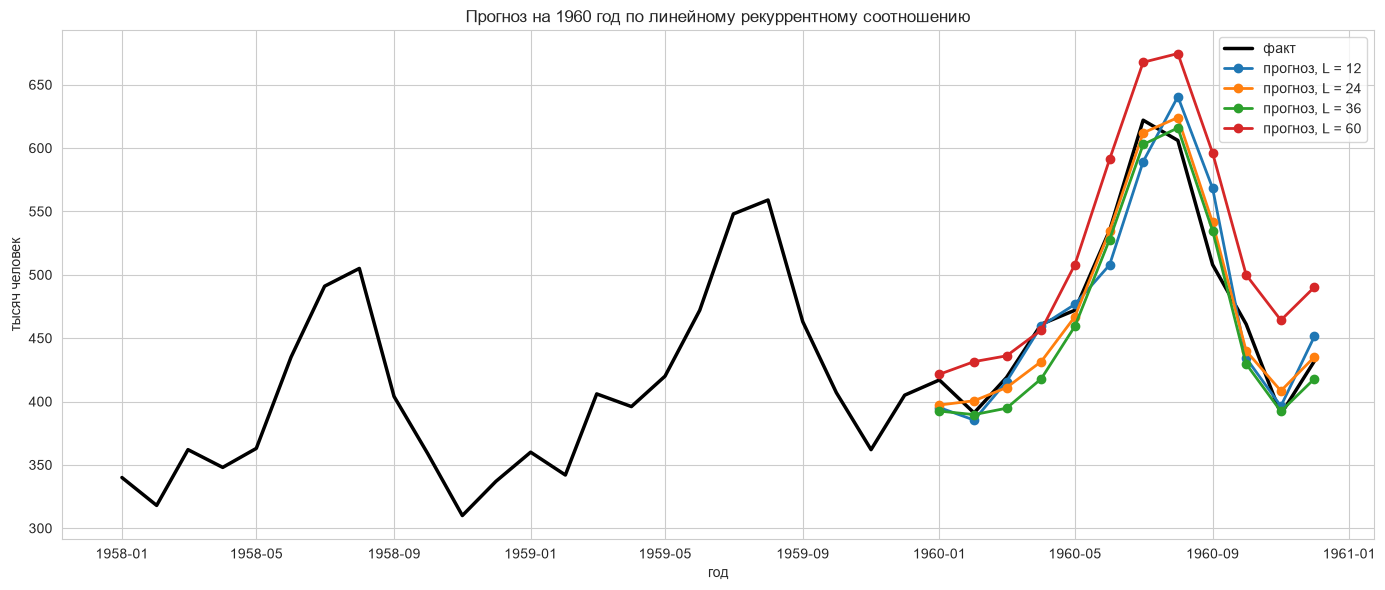

In [12]:
plt.figure(figsize=(14, 6))
plt.plot(ряд.index[-36:], ряд.values[-36:], lw=2.5, color='black', label='факт')
for L in [12, 24, 36, 60]:
    plt.plot(ряд.index[-12:], прогнозы[L], lw=2, marker='o', label=f'прогноз, L = {L}')
plt.title('Прогноз на 1960 год по линейному рекуррентному соотношению')
plt.xlabel('год')
plt.ylabel('тысяч человек')
plt.legend()
plt.tight_layout()
plt.show()

Двенадцать точек - короткий тест, и порядок мест на нем может оказаться случайностью.
Поэтому тот же расчет повторяется с пяти разных точек отсечения: каждый раз обучение
идет по всему ряду до отсечения, а проверка - по следующим 12 месяцам. Окна взяты
те три, которые проходят по длине на всех пяти отсечениях

In [13]:
окончания = [96, 108, 120, 132, 144]   # каждый раз отложены следующие 12 месяцев
устойчивость = []
for L in [12, 24, 36]:
    ошибки = [float(np.sqrt(((прогноз_лрс(ряд.values[:конец - 12], L, 7, 12)
                              - ряд.values[конец - 12:конец]) ** 2).mean()))
              for конец in окончания]
    устойчивость.append([f'L = {L}'] + [round(о, 2) for о in ошибки] + [round(float(np.mean(ошибки)), 2)])

ошибки_наивного = [float(np.sqrt(((ряд.values[конец - 24:конец - 12] - ряд.values[конец - 12:конец]) ** 2).mean()))
                   for конец in окончания]
устойчивость.append(['сезонный наивный'] + [round(о, 2) for о in ошибки_наивного]
                    + [round(float(np.mean(ошибки_наивного)), 2)])

столбцы = ['окно'] + [f'{ряд.index[конец - 1].year} год' for конец in окончания] + ['среднее']
print('RMSE прогноза на 12 месяцев с разных точек отсечения')
print(pd.DataFrame(устойчивость, columns=столбцы).to_string(index=False))

RMSE прогноза на 12 месяцев с разных точек отсечения
            окно  1956 год  1957 год  1958 год  1959 год  1960 год  среднее
          L = 12     15.89     16.37     42.95     18.35     26.34    23.98
          L = 24     14.32     17.03     39.00     61.09     17.72    29.83
          L = 36     16.96     15.54     43.88     49.76     21.65    29.56
сезонный наивный     45.18     41.47     17.01     49.25     50.71    40.73


**Вывод по дополнительному эксперименту:** на хвосте 1960 года прогноз по ЛРС обходит
сезонный наивный ориентир при любом окне, кроме самого длинного: RMSE 17.7-26.3 против
50.7 у наивного, а при `L = 60` соотношение уже 51.1 против 50.7, то есть преимущество
пропадает. Лучшим на этом хвосте выглядит `L = 24` (RMSE 17.7, MAPE 3.15%).

Проверка с пяти точек отсечения этот порядок мест не подтверждает. Ошибка одного и того
же окна гуляет от года к году в разы: у `L = 24` от 14.3 до 61.1, у `L = 36` от 15.5
до 49.8. В среднем по пяти отсечениям впереди оказывается `L = 12` с 23.98, а `L = 24`
и `L = 36` идут почти вровень - 29.83 и 29.56, то есть ровно наоборот к результату
на одном хвосте. Наивный ориентир в среднем хуже всех (40.73), но на 1958 годе он
обходит все три окна сразу.

Отсюда вывод: **двенадцати точек не хватает, чтобы различить окна
по качеству прогноза** - разброс между годами больше разницы между окнами. Выбор `L = 36`
из Задачи 4 сделан по разложению, и прогнозом он ни подтвержден, ни опровергнут